In [8]:
import os, sys
import pandas as pd
import numpy as np
from pathlib import Path
import csv
import json
import subprocess
import re
from pathlib import Path

# Display settings: do not abbreviate DataFrame output
pd.set_option("display.max_rows", None)        # show all rows
pd.set_option("display.max_columns", None)     # show all columns
pd.set_option("display.width", None)           # don't wrap to fit console width
pd.set_option("display.max_colwidth", None)    # don't truncate column contents


In [9]:
BASE_DIR = Path("responses/sachs")
SUMMARY_CSV = BASE_DIR / "eval_summary.csv"

df = pd.read_csv(SUMMARY_CSV)

In [10]:
# sachs_df = pd.read_csv("./responses/sachs/eval_summary.csv")

In [11]:
from pathlib import Path
import pandas as pd

base = Path("./responses/sachs")
rows = []

for anon in [0, 1]:
    suffix = "_anon" if anon == 1 else ""
    for obs in [100, 200, 1000, 5000, 8000]:
        for inter in [0,  50, 100, 200, 500]:
            csv_name = f"responses_obs{obs}_int{inter}_shuf1_p5{suffix}_summary_joint_gpt-5-mini.csv"
            csv_path = base / csv_name
            summary_path = csv_path.with_suffix(csv_path.suffix + ".summary.json")
            rows.append({
                "anonymize": anon,
                "obs_n": obs,
                "int_n": inter,
                "csv_exists": csv_path.exists(),
                "summary_exists": summary_path.exists(),
                "csv": str(csv_path),
            })

status_df = pd.DataFrame(rows).sort_values(["anonymize", "obs_n", "int_n"]).reset_index(drop=True)
# status_df


Plotting models: ['gpt-5-mini', 'gpt-5.2-pro', 'Qwen3-4B-Thinking-2507', 'Qwen2-0.5B-Instruct', 'Qwen3-8B', 'checkpoint-4', 'gpt-5-pro', 'gpt-5.2-mini', 'grpo_sachs_mix_onthefly_mp2', 'grpo_sft_8192', 'grpo_sft_8192_cd_focus', 'grpo_sft_8192_from4096', 'stage_3_obs100_int0_bootstrap', 'stage_3_obs100_int0_graph_scaled', 'stage_3_obs100_int0_retuned']


/tmp/ipykernel_2025287/2918615595.py:157: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(summarize_group)


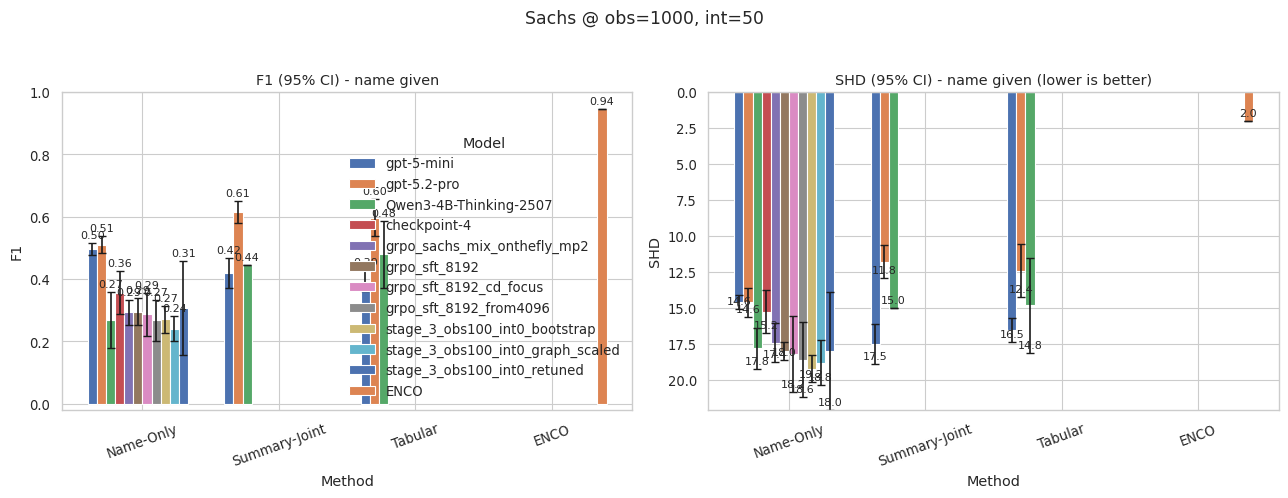

Saved: out/figures_pubready/sachs_obs1000_int50_name_given_avg_95ci.pdf


/tmp/ipykernel_2025287/2918615595.py:157: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(summarize_group)


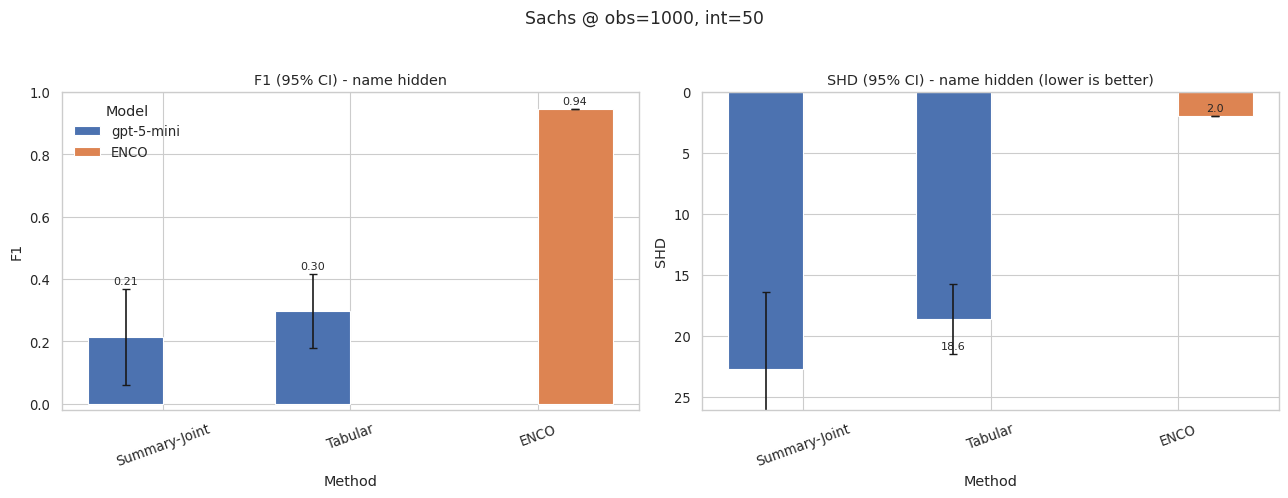

Saved: out/figures_pubready/sachs_obs1000_int50_name_hidden_avg_95ci.pdf


In [12]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# ---------- config ----------
summary_csv_new = "/home/yuen_chen/ENCO/experiments/out/experiment1/sachs_summary.csv"
summary_csv_old = "/home/yuen_chen/ENCO/experiments/out/experiment1/sachs_summary_old.csv"
qwen_model = "Qwen3-4B-Thinking-2507"

obs_target, int_target = 1000, 50
base_models = ["gpt-5-mini", "gpt-5.2-pro", qwen_model]
include_enco = True

metric = "avg"          # "avg" or "consensus"
err_level = "95ci"      # "se" or "95ci"
z = 1.96                # used when err_level == "95ci"
out_dir = Path("./out/figures_pubready")
# ----------------------------

f1_col, shd_col = f"{metric}_f1", f"{metric}_shd"

sns.set_theme(style="whitegrid", context="paper", font_scale=1.08)
plt.rcParams.update({"pdf.fonttype": 42, "ps.fonttype": 42})

new_df = pd.read_csv(summary_csv_new)
old_df = pd.read_csv(summary_csv_old)

# Optional legacy fix
new_df["model"] = new_df["model"].replace({"8192": "grpo_sft_8192"})

# Prefer rows from new_df when same setting appears in both
all_df = pd.concat([old_df, new_df], ignore_index=True)
dedup_keys = [
    c for c in [
        "dataset", "model", "prompt_style", "anonymize",
        "obs_n", "int_n", "row_order", "col_order", "shuf_n"
    ]
    if c in all_df.columns
]
df = all_df.drop_duplicates(subset=dedup_keys, keep="last") if dedup_keys else all_df.copy()

df = df[df["evaluated"] == 1].copy()

# unify SD columns across old/new schemas
if "avg_f1_sd" not in df.columns:
    df["avg_f1_sd"] = np.nan
if "avg_shd_sd" not in df.columns:
    df["avg_shd_sd"] = np.nan
if "var_f1_sd" in df.columns:
    df["avg_f1_sd"] = df["avg_f1_sd"].fillna(df["var_f1_sd"])
if "var_shd_sd" in df.columns:
    df["avg_shd_sd"] = df["avg_shd_sd"].fillna(df["var_shd_sd"])

# effective n (robust fallback chain)
df["n"] = pd.to_numeric(df.get("spread_n"), errors="coerce")
df["n"] = df["n"].fillna(pd.to_numeric(df.get("valid_rows"), errors="coerce"))
df["n"] = df["n"].fillna(pd.to_numeric(df.get("num_rows"), errors="coerce"))
df["n"] = df["n"].fillna(1.0).clip(lower=1.0)

# Repair misparsed local-model rows:
# examples:
#   p5_thinktags_matrix_checkpoint-4
#   p5_anon_thinktags_summary_joint_stage_3_obs100_int0_bootstrap
wrapped_local = (
    df["prompt_style"].eq("cases")
    & df["model"].astype(str).str.match(
        r"^p5_(?:anon_)?thinktags_(?:summary_joint|matrix)_", na=False
    )
)

df.loc[wrapped_local & df["model"].str.contains("summary_joint", na=False), "prompt_style"] = "summary_joint"
df.loc[wrapped_local & df["model"].str.contains("matrix", na=False), "prompt_style"] = "matrix"
df.loc[wrapped_local & df["model"].str.contains("_anon_", na=False), "anonymize"] = 1
df.loc[wrapped_local & ~df["model"].str.contains("_anon_", na=False), "anonymize"] = 0
df.loc[wrapped_local, "model"] = (
    df.loc[wrapped_local, "model"]
      .str.replace(r"^p5_(?:anon_)?thinktags_(?:summary_joint|matrix)_", "", regex=True)
)

# Anything evaluated that is not a base/API model or ENCO is treated as a GRPO/local method
excluded_models = set(base_models + ["ENCO"])
grpo_models = sorted(
    m for m in df["model"].dropna().astype(str).unique()
    if m not in excluded_models
)


models = list(dict.fromkeys(base_models + grpo_models))
print("Plotting models:", models)

df["method"] = df["prompt_style"].map({
    "summary_joint": "Summary-Joint",
    "matrix": "Tabular",
    "names_only": "Name-Only",
    "enco": "ENCO",
})
df = df[df["method"].notna()].copy()
df = df[(df["model"].isin(models)) | (df["method"] == "ENCO")].copy()

main = df[df["method"].isin(["Summary-Joint", "Tabular", "ENCO"])].copy()
main = main[(main["obs_n"] == obs_target) & (main["int_n"] == int_target)]
name_only = df[df["method"] == "Name-Only"].copy()
plot_df = pd.concat([main, name_only], ignore_index=True)

method_order = ["Name-Only", "Summary-Joint", "Tabular"] + (["ENCO"] if include_enco else [])
hue_order = models + (["ENCO"] if include_enco else [])

# numeric coercion
for c in [f1_col, shd_col, "avg_f1_sd", "avg_shd_sd", "n"]:
    if c in plot_df.columns:
        plot_df[c] = pd.to_numeric(plot_df[c], errors="coerce")

plot_df["model_group"] = plot_df["model"]
plot_df.loc[plot_df["method"] == "ENCO", "model_group"] = "ENCO"

def pooled_mean_sd(m, s, n):
    m = np.asarray(m, dtype=float)
    s = np.asarray(s, dtype=float)
    n = np.asarray(n, dtype=float)
    keep = np.isfinite(m) & np.isfinite(n) & (n > 0)
    m, s, n = m[keep], s[keep], n[keep]
    s = np.where(np.isfinite(s), s, 0.0)
    if len(m) == 0:
        return np.nan, np.nan, 0.0
    N = n.sum()
    mu = np.sum(n * m) / N
    ss_within = np.sum(np.maximum(n - 1.0, 0.0) * (s ** 2))
    ss_between = np.sum(n * (m - mu) ** 2)
    var = (ss_within + ss_between) / max(N - 1.0, 1.0)
    sd = np.sqrt(max(var, 0.0))
    return mu, sd, N

def summarize_group(g):
    f1_m, f1_sd, n1 = pooled_mean_sd(g[f1_col], g["avg_f1_sd"], g["n"])
    shd_m, shd_sd, n2 = pooled_mean_sd(g[shd_col], g["avg_shd_sd"], g["n"])
    f1_se = f1_sd / np.sqrt(max(n1, 1.0))
    shd_se = shd_sd / np.sqrt(max(n2, 1.0))
    mult = z if err_level == "95ci" else 1.0
    return pd.Series({
        "f1": f1_m, "f1_err": mult * f1_se,
        "shd": shd_m, "shd_err": mult * shd_se,
        "n_total": n1
    })

for anon_val, anon_label in [(0, "name_given"), (1, "name_hidden")]:
    sub = plot_df.copy()
    if anon_val == 1:
        sub = sub[sub["method"] != "Name-Only"]

    llm_mask = sub["method"] != "ENCO"
    sub = sub[(~llm_mask) | (sub["anonymize"] == anon_val)]

    agg = (
        sub.groupby(["model_group", "method"], as_index=False)
           .apply(summarize_group)
           .reset_index(drop=True)
    )
    agg = agg.dropna(subset=["f1", "shd"], how="all")
    if agg.empty:
        print(f"Skip {anon_label}: no rows")
        continue

    panel_method_order = [m for m in method_order if m in agg["method"].unique()]
    panel_hues = [h for h in hue_order if h in agg["model_group"].unique()]

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
    x = np.arange(len(panel_method_order))
    width = 0.8 / max(len(panel_hues), 1)

    for i, h in enumerate(panel_hues):
        d = agg[agg["model_group"] == h].set_index("method").reindex(panel_method_order)
        xpos = x - 0.4 + width / 2 + i * width

        y_f1 = d["f1"].to_numpy(float)
        e_f1 = d["f1_err"].fillna(0).to_numpy(float)
        y_shd = d["shd"].to_numpy(float)
        e_shd = d["shd_err"].fillna(0).to_numpy(float)

        b1 = axes[0].bar(xpos, y_f1, width=width, yerr=e_f1, capsize=3, label=h)
        b2 = axes[1].bar(xpos, y_shd, width=width, yerr=e_shd, capsize=3, label=h)

        axes[0].bar_label(b1, labels=[f"{v:.2f}" if pd.notna(v) else "" for v in y_f1], padding=2, fontsize=8)
        axes[1].bar_label(b2, labels=[f"{v:.1f}" if pd.notna(v) else "" for v in y_shd], padding=2, fontsize=8)

    for ax in axes:
        ax.set_xticks(x)
        ax.set_xticklabels(panel_method_order, rotation=20)

    err_txt = "95% CI" if err_level == "95ci" else "SE"

    axes[0].set_ylim(-0.02, 1.0)
    axes[0].set_title(f"F1 ({err_txt}) - {anon_label.replace('_', ' ')}")
    axes[0].set_xlabel("Method")
    axes[0].set_ylabel("F1")
    axes[0].legend(title="Model", frameon=False, loc="best")

    axes[1].set_title(f"SHD ({err_txt}) - {anon_label.replace('_', ' ')} (lower is better)")
    axes[1].set_xlabel("Method")
    axes[1].set_ylabel("SHD")
    ymax = np.nanmax(agg["shd"].to_numpy(float))
    axes[1].set_ylim(max(1.0, ymax * 1.15), 0)
    leg = axes[1].get_legend()
    if leg is not None:
        leg.remove()

    fig.suptitle(f"Sachs @ obs={obs_target}, int={int_target}", y=1.03)
    fig.tight_layout()

    out_dir.mkdir(parents=True, exist_ok=True)
    out_path = out_dir / f"sachs_obs{obs_target}_int{int_target}_{anon_label}_{metric}_{err_level}.pdf"
    fig.savefig(out_path, bbox_inches="tight")
    plt.show()
    print("Saved:", out_path)


Plotting models: ['gpt-5-mini', 'gpt-5.2-pro', 'Qwen3-4B-Thinking-2507', 'Qwen2-0.5B-Instruct', 'Qwen3-8B', 'checkpoint-4', 'gpt-5-pro', 'gpt-5.2-mini', 'grpo_sachs_mix_onthefly_mp2', 'grpo_sft_8192', 'grpo_sft_8192_cd_focus', 'grpo_sft_8192_from4096', 'stage_3_obs100_int0_bootstrap', 'stage_3_obs100_int0_graph_scaled', 'stage_3_obs100_int0_retuned']


/tmp/ipykernel_2025287/1610024325.py:135: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(summarize_valid_rate)


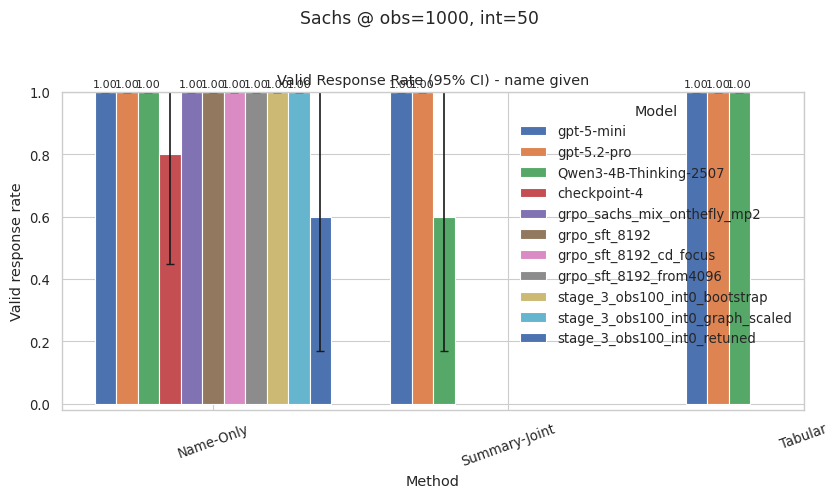

Saved: out/figures_pubready/sachs_obs1000_int50_name_given_valid_rate_95ci.pdf


/tmp/ipykernel_2025287/1610024325.py:135: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(summarize_valid_rate)


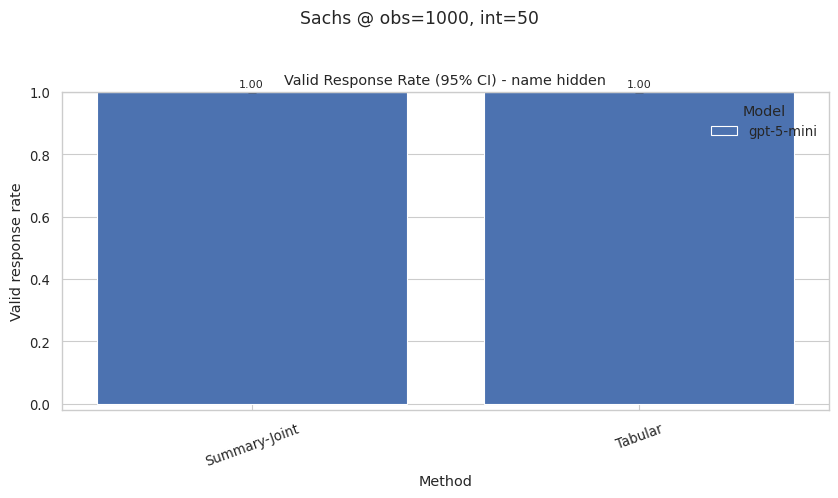

Saved: out/figures_pubready/sachs_obs1000_int50_name_hidden_valid_rate_95ci.pdf


In [13]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# ---------- config ----------
summary_csv_new = "/home/yuen_chen/ENCO/experiments/out/experiment1/sachs_summary.csv"
summary_csv_old = "/home/yuen_chen/ENCO/experiments/out/experiment1/sachs_summary_old.csv"
qwen_model = "Qwen3-4B-Thinking-2507"

obs_target, int_target = 1000, 50
base_models = ["gpt-5-mini", "gpt-5.2-pro", qwen_model]
include_enco = True

err_level = "95ci"      # "se" or "95ci"
z = 1.96
out_dir = Path("./out/figures_pubready")
# ----------------------------

sns.set_theme(style="whitegrid", context="paper", font_scale=1.08)
plt.rcParams.update({"pdf.fonttype": 42, "ps.fonttype": 42})

new_df = pd.read_csv(summary_csv_new)
old_df = pd.read_csv(summary_csv_old)

new_df["model"] = new_df["model"].replace({"8192": "grpo_sft_8192"})

all_df = pd.concat([old_df, new_df], ignore_index=True)
dedup_keys = [
    c for c in [
        "dataset", "model", "prompt_style", "anonymize",
        "obs_n", "int_n", "row_order", "col_order", "shuf_n"
    ]
    if c in all_df.columns
]
df = all_df.drop_duplicates(subset=dedup_keys, keep="last") if dedup_keys else all_df.copy()

df = df[df["evaluated"] == 1].copy()

# effective n
df["n"] = pd.to_numeric(df.get("spread_n"), errors="coerce")
df["n"] = df["n"].fillna(pd.to_numeric(df.get("num_rows"), errors="coerce"))
df["n"] = df["n"].fillna(1.0).clip(lower=1.0)

# valid response rate = valid_rows / num_rows
df["valid_rows_num"] = pd.to_numeric(df.get("valid_rows"), errors="coerce")
df["num_rows_num"] = pd.to_numeric(df.get("num_rows"), errors="coerce")
df["valid_rate"] = np.where(
    df["num_rows_num"] > 0,
    df["valid_rows_num"] / df["num_rows_num"],
    np.nan,
)

wrapped_local = (
    df["prompt_style"].eq("cases")
    & df["model"].astype(str).str.match(
        r"^p5_(?:anon_)?thinktags_(?:summary_joint|matrix)_", na=False
    )
)

df.loc[wrapped_local & df["model"].str.contains("summary_joint", na=False), "prompt_style"] = "summary_joint"
df.loc[wrapped_local & df["model"].str.contains("matrix", na=False), "prompt_style"] = "matrix"
df.loc[wrapped_local & df["model"].str.contains("_anon_", na=False), "anonymize"] = 1
df.loc[wrapped_local & ~df["model"].str.contains("_anon_", na=False), "anonymize"] = 0
df.loc[wrapped_local, "model"] = (
    df.loc[wrapped_local, "model"]
      .str.replace(r"^p5_(?:anon_)?thinktags_(?:summary_joint|matrix)_", "", regex=True)
)

excluded_models = set(base_models + ["ENCO"])
grpo_models = sorted(
    m for m in df["model"].dropna().astype(str).unique()
    if m not in excluded_models
)

models = list(dict.fromkeys(base_models + grpo_models))
print("Plotting models:", models)

df["method"] = df["prompt_style"].map({
    "summary_joint": "Summary-Joint",
    "matrix": "Tabular",
    "names_only": "Name-Only",
    "enco": "ENCO",
})
df = df[df["method"].notna()].copy()
df = df[(df["model"].isin(models)) | (df["method"] == "ENCO")].copy()

main = df[df["method"].isin(["Summary-Joint", "Tabular", "ENCO"])].copy()
main = main[(main["obs_n"] == obs_target) & (main["int_n"] == int_target)]
name_only = df[df["method"] == "Name-Only"].copy()
plot_df = pd.concat([main, name_only], ignore_index=True)

method_order = ["Name-Only", "Summary-Joint", "Tabular"] + (["ENCO"] if include_enco else [])
hue_order = models + (["ENCO"] if include_enco else [])

for c in ["valid_rate", "n", "valid_rows_num", "num_rows_num"]:
    if c in plot_df.columns:
        plot_df[c] = pd.to_numeric(plot_df[c], errors="coerce")

plot_df["model_group"] = plot_df["model"]
plot_df.loc[plot_df["method"] == "ENCO", "model_group"] = "ENCO"

def summarize_valid_rate(g):
    g = g.copy()
    keep = np.isfinite(g["valid_rate"]) & np.isfinite(g["num_rows_num"]) & (g["num_rows_num"] > 0)
    g = g[keep]
    if len(g) == 0:
        return pd.Series({"valid_rate": np.nan, "valid_rate_err": np.nan, "n_total": 0.0})

    # pool Bernoulli counts via total successes / total trials
    successes = g["valid_rows_num"].sum()
    trials = g["num_rows_num"].sum()
    p = successes / trials if trials > 0 else np.nan

    se = np.sqrt(p * (1 - p) / trials) if trials > 0 and np.isfinite(p) else np.nan
    mult = z if err_level == "95ci" else 1.0

    return pd.Series({
        "valid_rate": p,
        "valid_rate_err": mult * se if np.isfinite(se) else np.nan,
        "n_total": trials
    })

for anon_val, anon_label in [(0, "name_given"), (1, "name_hidden")]:
    sub = plot_df.copy()
    if anon_val == 1:
        sub = sub[sub["method"] != "Name-Only"]

    llm_mask = sub["method"] != "ENCO"
    sub = sub[(~llm_mask) | (sub["anonymize"] == anon_val)]

    agg = (
        sub.groupby(["model_group", "method"], as_index=False)
           .apply(summarize_valid_rate)
           .reset_index(drop=True)
    )
    agg = agg.dropna(subset=["valid_rate"], how="all")
    if agg.empty:
        print(f"Skip {anon_label}: no rows")
        continue

    panel_method_order = [m for m in method_order if m in agg["method"].unique()]
    panel_hues = [h for h in hue_order if h in agg["model_group"].unique()]

    fig, ax = plt.subplots(1, 1, figsize=(8.5, 4.8))
    x = np.arange(len(panel_method_order))
    width = 0.8 / max(len(panel_hues), 1)

    for i, h in enumerate(panel_hues):
        d = agg[agg["model_group"] == h].set_index("method").reindex(panel_method_order)
        xpos = x - 0.4 + width / 2 + i * width

        y = d["valid_rate"].to_numpy(float)
        e = d["valid_rate_err"].fillna(0).to_numpy(float)

        bars = ax.bar(xpos, y, width=width, yerr=e, capsize=3, label=h)
        ax.bar_label(bars, labels=[f"{v:.2f}" if pd.notna(v) else "" for v in y], padding=2, fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels(panel_method_order, rotation=20)

    err_txt = "95% CI" if err_level == "95ci" else "SE"
    ax.set_ylim(-0.02, 1.0)
    ax.set_title(f"Valid Response Rate ({err_txt}) - {anon_label.replace('_', ' ')}")
    ax.set_xlabel("Method")
    ax.set_ylabel("Valid response rate")
    ax.legend(title="Model", frameon=False, loc="best")

    fig.suptitle(f"Sachs @ obs={obs_target}, int={int_target}", y=1.03)
    fig.tight_layout()

    out_dir.mkdir(parents=True, exist_ok=True)
    out_path = out_dir / f"sachs_obs{obs_target}_int{int_target}_{anon_label}_valid_rate_{err_level}.pdf"
    fig.savefig(out_path, bbox_inches="tight")
    plt.show()
    print("Saved:", out_path)


In [14]:
import json, glob
import pandas as pd
from pathlib import Path

root = Path("/home/yuen_chen/ENCO/experiments/checkpoints/grpo_sft_8192_cd_focus_sachs_curriculum")
rows = []
for p in sorted(root.glob("stage_*_obs*_int*/grpo_log/train_metrics.jsonl")):
    stage = p.parts[-3]
    with open(p) as f:
        logs = [json.loads(x) for x in f if x.strip()]
    if not logs:
        continue
    last = logs[-1]
    rows.append({
        "stage": stage,
        "global_step": last.get("global_step"),
        "reward": last.get("reward"),
        "fmt": last.get("rewards/cd_format_reward/mean"),
        "cd": last.get("rewards/cd_graph_reward/mean"),
        "pfmt": last.get("rewards/cd_partial_format_reward/mean"),
        "clipped_ratio": last.get("completions/clipped_ratio"),
        "mean_len": last.get("completions/mean_length"),
        "term_len": last.get("completions/mean_terminated_length"),
    })

df = pd.DataFrame(rows).sort_values("stage")
display(df)


,stage,global_step,reward,fmt,cd,pfmt,clipped_ratio,mean_len,term_len
0,stage_10_obs100_int10,18,-0.129622,0.1875,0.000000,0.060938,0.6875,7560.9375,2948.5625
1,stage_11_obs100_int50,18,-0.131975,0.1875,0.000000,0.062500,0.7500,7639.7500,2991.5000
2,stage_12_obs100_int100,10,-0.116225,0.2000,0.000000,0.075000,0.8000,7824.7000,2542.2000
3,stage_1_obs0_int0,18,1.322698,1.0000,0.356680,0.225000,0.0000,5180.6875,5180.6875
4,stage_2_obs0_int10,18,-0.283178,0.0625,0.000000,0.059375,0.8125,8101.2500,1885.1875
5,stage_3_obs0_int50,18,-0.217962,0.1250,0.000000,0.059375,0.8125,8046.9375,2781.8750
6,stage_4_obs0_int100,18,-0.289500,0.0625,0.000000,0.053125,0.9375,8103.1875,846.3750
7,stage_5_obs50_int0,18,0.922603,0.7500,0.284043,0.164062,0.2500,5510.8125,3462.8125
8,stage_6_obs50_int10,18,-0.155750,0.1875,0.000000,0.053125,0.8125,7927.6875,2543.3750
9,stage_7_obs50_int50,18,-0.252425,0.0625,0.000000,0.087500,0.8750,8048.6250,880.6250


In [21]:
df[df["model"].str.contains("grpo", case=False, na=False)][
    ["model","var_f1_sd","var_shd_sd","avg_f1_sd","avg_shd_sd","valid_rows","num_rows","spread_n"]
].head(20)


KeyError: 'model'

In [ ]:
import pandas as pd

s = pd.read_csv("/home/yuen_chen/ENCO/experiments/out/experiment1/sachs_summary.csv")
g = s[s["model"].astype(str).str.contains("grpo", case=False, na=False)].copy()

# fix misparsed GRPO rows
m = g["prompt_style"].eq("cases")
g.loc[m & g["model"].str.contains("summary_joint", na=False), "prompt_style"] = "summary_joint"
g.loc[m & g["model"].str.contains("matrix", na=False), "prompt_style"] = "matrix"
g.loc[m & g["model"].str.contains("_anon_", na=False), "anonymize"] = 1
g.loc[m & ~g["model"].str.contains("_anon_", na=False), "anonymize"] = 0
g.loc[m, "model"] = (
    g.loc[m, "model"]
      .str.replace(r"^p5_(?:anon_)?thinktags_(?:summary_joint|matrix)_", "", regex=True)
)

g = g[g["evaluated"] == 1].copy()

# choose existing count columns
row_cols = [c for c in ["n_rows", "num_rows"] if c in g.columns]
valid_cols = [c for c in ["n_valid_rows", "valid_rows"] if c in g.columns]

cols = [
    "model","prompt_style","anonymize","obs_n","int_n",
    *row_cols, *valid_cols,
    "avg_f1","avg_shd","consensus_f1","consensus_shd"
]
cols = [c for c in cols if c in g.columns]

display(g[cols].sort_values(["model","prompt_style","anonymize","obs_n","int_n"]))

agg_spec = {
    "mean_avg_f1": ("avg_f1","mean"),
    "mean_avg_shd": ("avg_shd","mean"),
    "mean_cons_f1": ("consensus_f1","mean"),
    "mean_cons_shd": ("consensus_shd","mean"),
    "cells": ("avg_f1","count"),
}
if "n_rows" in g.columns:
    agg_spec["sum_n_rows"] = ("n_rows","sum")
elif "num_rows" in g.columns:
    agg_spec["sum_n_rows"] = ("num_rows","sum")

if "n_valid_rows" in g.columns:
    agg_spec["sum_n_valid_rows"] = ("n_valid_rows","sum")
elif "valid_rows" in g.columns:
    agg_spec["sum_n_valid_rows"] = ("valid_rows","sum")

agg = (
    g.groupby(["model","prompt_style","anonymize"], as_index=False)
     .agg(**agg_spec)
     .sort_values(["model","prompt_style","anonymize"])
)

display(agg)


,model,prompt_style,anonymize,obs_n,int_n,num_rows,valid_rows,avg_f1,avg_shd,consensus_f1,consensus_shd
19,grpo_sft_8192,matrix,0,0.0,200.0,5,5,0.429630,15.400000,0.444444,15.0
43,grpo_sft_8192,matrix,0,5000.0,0.0,5,5,0.425926,17.000000,0.190476,17.0
63,grpo_sft_8192,matrix,0,5000.0,200.0,5,5,0.425519,17.800000,0.384615,16.0
8,grpo_sft_8192,matrix,1,0.0,200.0,5,5,0.358796,18.000000,0.105263,17.0
33,grpo_sft_8192,matrix,1,5000.0,0.0,5,5,0.325926,18.200000,NaN,18.0
53,grpo_sft_8192,matrix,1,5000.0,200.0,5,2,0.384615,16.500000,NaN,17.0
3,grpo_sft_8192,names_only,0,NaN,NaN,5,5,0.294872,18.000000,0.190476,17.0
24,grpo_sft_8192,summary_joint,0,0.0,200.0,5,1,0.444444,15.000000,0.444444,15.0
48,grpo_sft_8192,summary_joint,0,5000.0,0.0,5,4,0.430108,16.000000,0.444444,15.0
68,grpo_sft_8192,summary_joint,0,5000.0,200.0,5,3,0.444444,15.000000,0.444444,15.0


,model,prompt_style,anonymize,mean_avg_f1,mean_avg_shd,mean_cons_f1,mean_cons_shd,cells,sum_n_rows,sum_n_valid_rows
0,grpo_sft_8192,matrix,0,0.427025,16.733333,0.339845,16.000000,3,15,15
1,grpo_sft_8192,matrix,1,0.356446,17.566667,0.105263,17.333333,3,15,12
2,grpo_sft_8192,names_only,0,0.294872,18.000000,0.190476,17.000000,1,5,5
3,grpo_sft_8192,summary_joint,0,0.439665,15.333333,0.444444,15.000000,3,15,8
4,grpo_sft_8192,summary_joint,1,0.444444,17.133333,0.444444,15.666667,3,15,10
5,grpo_sft_8192_cd_focus,matrix,0,0.377598,17.266667,0.444444,16.666667,3,15,15
6,grpo_sft_8192_cd_focus,matrix,1,0.317063,18.966667,0.105263,18.000000,3,15,12
7,grpo_sft_8192_cd_focus,names_only,0,0.286454,18.200000,0.181818,18.000000,1,5,5
8,grpo_sft_8192_cd_focus,summary_joint,0,0.405435,15.883333,0.354999,15.333333,3,15,11
9,grpo_sft_8192_cd_focus,summary_joint,1,0.395330,16.000000,0.322222,15.500000,2,15,7


In [ ]:
import pandas as pd

s = pd.read_csv("/home/yuen_chen/ENCO/experiments/out/experiment1/sachs_summary.csv")
g = s[s["model"].astype(str).str.contains("grpo", case=False, na=False)].copy()

print("All GRPO rows by method/obs/int/evaluated:")

g.groupby(["model","prompt_style","obs_n","int_n","evaluated"], dropna=False).size().reset_index(name="n").sort_values(["model","prompt_style","obs_n","int_n","evaluated"])



All GRPO rows by method/obs/int/evaluated:


,model,prompt_style,obs_n,int_n,evaluated,n
0,grpo_sft_8192,names_only,NaN,NaN,1,1
1,grpo_sft_8192_from4096,names_only,NaN,NaN,1,1
2,p5_anon_thinktags_matrix_grpo_sft_8192,cases,0.0,200.0,1,1
3,p5_anon_thinktags_matrix_grpo_sft_8192,cases,5000.0,0.0,1,1
4,p5_anon_thinktags_matrix_grpo_sft_8192,cases,5000.0,200.0,1,1
5,p5_anon_thinktags_matrix_grpo_sft_8192_from4096,cases,0.0,200.0,1,1
6,p5_anon_thinktags_matrix_grpo_sft_8192_from4096,cases,5000.0,0.0,1,1
7,p5_anon_thinktags_matrix_grpo_sft_8192_from4096,cases,5000.0,200.0,1,1
8,p5_anon_thinktags_summary_joint_grpo_sft_8192,cases,0.0,200.0,1,1
9,p5_anon_thinktags_summary_joint_grpo_sft_8192,cases,5000.0,0.0,1,1


In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# ---------- config ----------
summary_csv = "./out/experiment1/diabetes_summary.csv"
obs_target, int_target = 5000, 200
metric = "avg"  # fixed as requested
models = ["gpt-5-mini", "gpt-5.2-pro", "Qwen3-4B-Thinking-2507"]
include_enco = True
out_dir = Path("./out/figures_pubready")
# ----------------------------

f1_col, shd_col = f"{metric}_f1", f"{metric}_shd"
sns.set_theme(style="whitegrid", context="paper", font_scale=1.08)
plt.rcParams.update({"pdf.fonttype": 42, "ps.fonttype": 42})

df = pd.read_csv(summary_csv)
df = df[df["evaluated"] == 1].copy()

# map methods
df["method"] = df["prompt_style"].map({
    # "summary": "Summary",
    "summary_joint": "Summary-Joint",
    "matrix": "Tabular",
    "names_only": "Name-Only",
    "enco": "ENCO",
})
df = df[df["method"].notna()].copy()

# keep selected models (+ ENCO)
df = df[(df["model"].isin(models)) | (df["method"] == "ENCO")].copy()

# split: main configs at obs/int, plus names-only (obs/int independent)
main = df[df["method"].isin([ "Summary-Joint", "Tabular", "ENCO"])].copy()
main = main[(main["obs_n"] == obs_target) & (main["int_n"] == int_target)]

name_only = df[df["method"] == "Name-Only"].copy()
plot_df = pd.concat([main, name_only], ignore_index=True)

method_order = ["Name-Only", "Summary-Joint", "Tabular"] + (["ENCO"] if include_enco else [])

# one plot for non-anon, one for anon
for anon_val, anon_label in [(0, "name_given"), (1, "name_hidden")]:
    sub = plot_df.copy()
    # omit Name-Only for name-hidden panel
    if anon_val == 1:
        sub = sub[sub["method"] != "Name-Only"]

    # ENCO shown in both plots; LLM methods filtered by anonymize
    llm_mask = sub["method"] != "ENCO"
    sub = sub[(~llm_mask) | (sub["anonymize"] == anon_val)]

    # aggregate duplicates
    agg = (sub.groupby(["model", "method"], as_index=False)
             .agg(f1=(f1_col, "mean"), shd=(shd_col, "mean")))

    # ENCO bar uses label "ENCO"
    agg["model_group"] = agg["model"]
    agg.loc[agg["method"] == "ENCO", "model_group"] = "ENCO"

    hue_order = models + (["ENCO"] if include_enco else [])
    agg["method"] = pd.Categorical(agg["method"], categories=method_order, ordered=True)
    panel_method_order = [m for m in method_order if m in agg["method"].unique()]

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

    sns.barplot(
        data=agg, x="method", y="f1", hue="model_group",
        order=panel_method_order, hue_order=hue_order, errorbar=None, ax=axes[0]
    )
    axes[0].set_ylim(-0.02, 1.0)   # instead of (0, 1)
    axes[0].set_title(f"F1 ({metric}) - {anon_label.replace('_',' ')}")
    axes[0].set_xlabel("Method")
    axes[0].set_ylabel("F1")
    # axes[0].set_ylim(0, 1)
    axes[0].tick_params(axis="x", rotation=20)
    axes[0].legend(title="Model", frameon=False, loc="best")



    sns.barplot(
        data=agg, x="method", y="shd", hue="model_group",
        order=panel_method_order, hue_order=hue_order, errorbar=None, ax=axes[1]
    )
    axes[1].set_title(f"SHD ({metric}) - {anon_label.replace('_',' ')} (lower is better)")
    axes[1].set_xlabel("Method")
    axes[1].set_ylabel("SHD")
    axes[1].tick_params(axis="x", rotation=20)
    # axes[1].set_ylim(-0.02, 25.0)
    axes[1].invert_yaxis()   # <-- key line
    axes[1].legend_.remove()

    # F1 labels
    for c in axes[0].containers:
        vals = c.datavalues
        labels = [f"{v:.2f}" if pd.notna(v) else "" for v in vals]
        axes[0].bar_label(c, labels=labels, padding=2, fontsize=8)

    # SHD labels (below bars; axis inverted)
    for c in axes[1].containers:
        vals = c.datavalues
        labels = [f"{v:.1f}" if pd.notna(v) else "" for v in vals]
        axes[1].bar_label(c, labels=labels, padding=2, fontsize=8)

    fig.suptitle(f"Sachs @ obs={obs_target}, int={int_target}", y=1.03)
    fig.tight_layout()

    out_path = out_dir / f"sachs_obs{obs_target}_int{int_target}_{anon_label}_{metric}_with_name_only.pdf"
    out_dir.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_path, bbox_inches="tight")
    plt.show()
    print("Saved:", out_path)


FileNotFoundError: [Errno 2] No such file or directory: './out/experiment1/diabetes_summary.csv'